# Using Stochastic Gates for Features Selection

This tutorial demonstrates how to use Captum's Stochastic Gates for feature selection. In the following tutorial, we will create a synthesized regression dataset with many noisy features and build a neural network with Stochatisc Gates which learns to get rid of useless features during training. We will verify if the Stochastic Gates can improve the model's perfromance and compare different Stochastic Gates within Captum.

In [158]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt
import random
import numpy as np

# Setting seed for reproducibility
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True

g = torch.Generator()
g.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

import sys
sys.path.insert(0, '/home/aoboyang/local/captum')

## Dataset

To highlight the effect of feature selection, we will use [the Friedman dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_friedman1.html), a synthesized regression dataset, whose label is actually only decided by 5 features following the equation

$Y = 10 \sin(\pi X_1 X_2) + 20(X_3 - 0.5)^2 + 10X_4 + 5X_5 + \zeta \text{ where } \zeta \sim \mathcal{N}(0,1)$

while it can sample number of random noises as other features. To make the task more challenging, we will create 500 input features (495 unused features + 5 actually used features) and have 500 examples which is split into 80%/20% for train/test so the number of training examples is less than the number of feature. `sklearn` provides the built-in utility to generate the Friedman dataset, so we will just use it to create the raw data.

In [159]:
from sklearn import datasets

n_features = 500
n_data = 600
split_ratios = [0.75, 0.25]

X, Y = datasets.make_friedman1(n_data, n_features, noise=1, random_state=0)

In [160]:
# import math
# import numpy as np
# X, Y = datasets.make_friedman1(5, 10, noise=0, random_state=0)
# print(X)
# print(Y)
# print(10 * np.sin(math.pi * X[:, 0] * X[:, 1]))
# print(20 * ((X[:, 2] - 0.5) ** 2))
# print(10 * X[:, 3])
# 10 * np.sin(math.pi * X[:, 0] * X[:, 1]) + 20 * ((X[:, 2] - 0.5) ** 2) + 10 * X[:, 3] + 5 * X[:, 4]

Next, we will make a PyTorch `Dataset` for our data and split it into train/val/test based on the defined ratios.

In [161]:
class FriedmanDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]
    
train_dataset, test_dataset = torch.utils.data.random_split(FriedmanDataset(X, Y), split_ratios)
print("training data length:", len(train_dataset))
print("testing data length:", len(test_dataset))

training data length: 450
testing data length: 150


At last, wrap them into the corresponding PyTorch `DataLoader` and verify the shapes of the bactehd inputs and labels. 

In [162]:
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

x, y = next(iter(train_loader))
print("batched inputs shape:", x.shape)
print("batched lables shape:", y.shape)

batched inputs shape: torch.Size([10, 500])
batched lables shape: torch.Size([10])


## Model and Training

### Model with Stochastic Gates

The baseline model we will use for our regression task is a simple 3-layer MLP. On top it, we will integrate an extra Stochastic Gates layer into the model. Captum provides variants of Stochastic Gates implementations based on different distributions, including `BinaryConcreteStochasticGates` and `GaussianStochasticGates`. As the names suggest, one uses Binary Concrete distribution to approximate the Bernoulli gate and the other uses Gaussian distribution. For readers who need more details of the algorithms, please go to [our documentation](https://captum.ai/api/module) and check the original papers

- [Learning Sparse Neural Networks through L0 regularization](https://arxiv.org/abs/1712.01312)
- [Feature Selection using Stochastic Gates](https://arxiv.org/abs/1810.04247)

Let's first import the Stochastic Gates classes from Captum and initiate them. The only mandatory argument needed is `n_gates`, number of gates. Since we want to do feature selection, there should be an independent gate for each feature to decide if the corresponding feature should be used or not. So `n_gates` should equal to `n_features`. 


In [192]:
from captum.module import (
  BinaryConcreteStochasticGates, 
  GaussianStochasticGates, 
)

bc_stg = BinaryConcreteStochasticGates(n_features, reg_weight=1e-4)
g_stg = GaussianStochasticGates(n_features, reg_weight=1e-2)

As you can see, we also customized `reg_weight`, regularization weight, which is the coefficient multiplied on the regularization term that will be later returned. The argument serves the same purpose as `weight_decay` for [L^2 Regularization in PyTorch](https://pytorch.org/docs/stable/optim.html). Its value decides the extend of the regularization which forces sparcity to the gates. So larger `reg_weight` will cause more gates turning to `0` and smaller `reg_weight` will cause more gates turning to `1`, which means using less features or more features respectively in our application. But it is totally optional to set the weight here. You can scale the regularization yourself anytime before calling `backward`.

Next, we will define a flexible MLP module that allows us to inject different Stochastic Gates instances. The StochasticGates instance is saved under `self.stg` and you can check the `forward` method to see how it is used. Since it inherits PyTorch `Module`, it can be directly used as `Callable`, which takes a single tensor as input whose 1st dimension should be batch size and returns the gated input of the same shape and an additional regularization scalar used to optimize the sparsity of the gates. We initiate three model instances: one without StochasticGates as the baseline; the other two for our two different variants.

In [194]:
class STG_MLP(nn.Module):
    def __init__(self, input_size, stg=None):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_size, 50),
            nn.Tanh(),
            nn.Linear(50, 10),
            nn.Tanh(),
            nn.Linear(10, 1),
        )

        self.stg = stg
        
    def forward(self, x):
        """
        Args:
          x (Tensor): input tensor in shape(batch_size, n_features)
        Returns:          
          y (Tensor): module output in shape(batch_size, 1)
          reg (Tensor): regularization, scalar
        """
        # pass input through gates first
        if self.stg is not None:
            x, reg = self.stg(x)
        else:
            # dummy regularization term
            reg = torch.tensor(0.0)

        return self.mlp(x).squeeze(-1), reg
    
baseline_model = STG_MLP(n_features).to(device).double()
bc_model = STG_MLP(n_features, stg=bc_stg).to(device).double()
g_model = STG_MLP(n_features, stg=g_stg).to(device).double()

### Training

The training process is the same as training any regular neural networks except we need also include the regularization loss of the StochasticGates into the optimization objective.

One deviation is the outputs of our model's `forward()`, which now also returns the loss of the embedded Stochastic Gates. This loss should be added to the overall loss while performing back-propragation and SGD.

The following steps can vary depends on your specific model, but the overall idea should be somewhat consistent.

In [190]:
def train_epoch(dataloader, model, loss_fn, optimizer, print_result=False):
    model.train(True)
    pred_loss_sum = 0.0
    reg_loss_sum = 0.0
    n_batches = len(dataloader)

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
                
        pred, reg_loss = model(inputs)
        pred_loss = loss_fn(pred, labels)

        # add StochasticGates regularization loss into the loss of model predictions
        loss = pred_loss + reg_loss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred_loss_sum += pred_loss.item()
        
        reg_loss_sum += reg_loss.item() / model.stg.reg_weight / n_features
    
    return pred_loss_sum / n_batches, reg_loss_sum / n_batches

def test_epoch(dataloader, model, loss_fn, print_result=False):
    model.train(False)
    n_batches = len(dataloader)
    pred_loss_sum = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            pred, reg_loss = model(inputs)
            pred_loss = loss_fn(pred, labels)
            pred_loss_sum += pred_loss.item()

    return pred_loss_sum / n_batches
    
    
def train_model(model, learning_rate, n_epochs):
    # List to keep track of losses
    train_pred_losses = list()
    train_reg_losses = list()
    test_pred_losses = list()

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for t in range(n_epochs):
        pred_loss, reg_loss = train_epoch(train_loader, model, loss_fn, optimizer)
        
        train_pred_losses.append(pred_loss)
        train_reg_losses.append(reg_loss)

        pred_loss = test_epoch(train_loader, model, loss_fn)
        test_pred_losses.append(pred_loss)
    
    plt.figure(figsize=(10,5))

    plt.plot(list(range(n_epochs)), train_pred_losses, label='Train loss')
    plt.plot(list(range(n_epochs)), test_pred_losses, label='Test loss')
    plt.legend()
    
    plt.show()
    
    if model.stg:
        print(train_reg_losses)
        plt.plot(list(range(n_epochs)), train_reg_losses, label='Regularization')
        plt.show()

    print("Test loss:", pred_loss)
    
LR = 1e-2
# train_model(baseline_model, LR, 200)

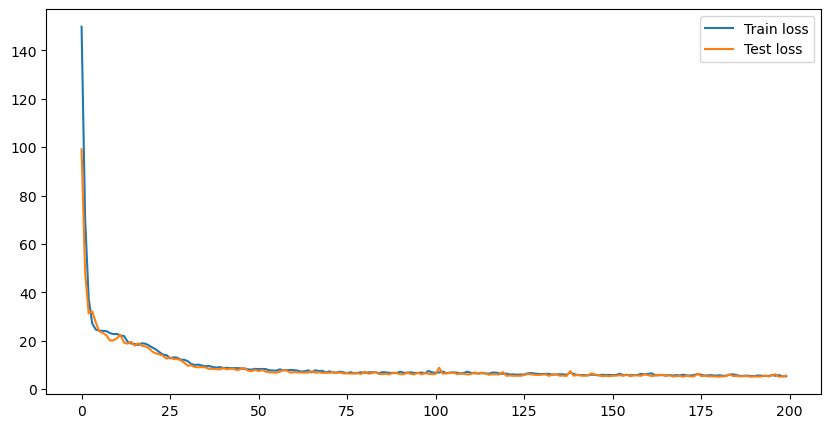

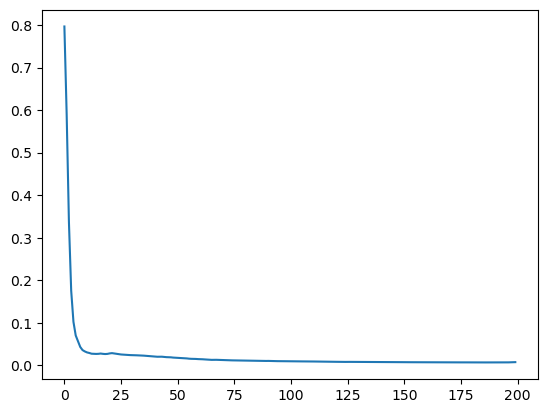

Test loss: 5.576295440583602


In [166]:
train_model(g_model, LR, 200)

In [167]:
g_model.stg.get_gate_active_probs()

tensor([1.0000e+00, 1.0000e+00, 5.8354e-04, 1.0000e+00, 5.0856e-01, 8.1221e-05,
        2.5295e-04, 9.0192e-05, 3.3462e-05, 3.7487e-05, 4.2301e-05, 3.5601e-05,
        4.1582e-04, 6.3646e-05, 1.8706e-05, 9.2762e-06, 5.3162e-05, 4.9668e-04,
        1.1552e-05, 3.7078e-05, 1.2411e-04, 1.2769e-06, 1.3321e-03, 4.1154e-05,
        1.0857e-05, 2.1219e-03, 8.9773e-04, 2.6589e-04, 1.3682e-04, 4.3843e-04,
        2.5200e-05, 5.2343e-04, 8.1749e-06, 2.7538e-04, 1.1103e-04, 2.4202e-04,
        4.1294e-06, 2.0883e-04, 2.7091e-04, 1.4817e-04, 5.8972e-04, 1.8762e-04,
        5.7635e-04, 2.7012e-06, 4.4685e-04, 4.0957e-05, 1.8234e-05, 4.4462e-06,
        8.0807e-04, 8.5589e-04, 1.6515e-04, 9.1020e-05, 2.3694e-05, 1.8670e-04,
        1.5797e-05, 4.4115e-06, 2.4207e-04, 1.2880e-05, 3.2943e-04, 8.2424e-04,
        3.5451e-04, 2.1040e-05, 7.4720e-05, 6.3689e-05, 1.1846e-05, 4.2711e-04,
        6.3199e-06, 6.5568e-05, 1.6700e-03, 7.5722e-05, 2.0933e-05, 2.9635e-04,
        1.1491e-05, 2.7930e-05, 4.1688e-

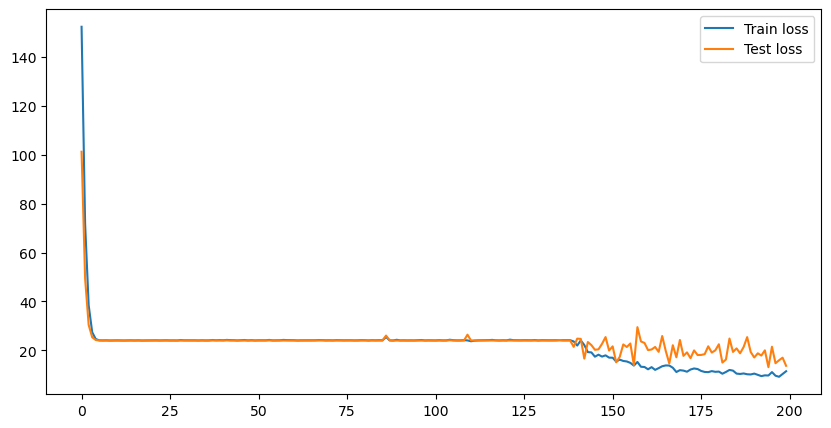

[0.83267955921299, 0.832477261178181, 0.8316849595258783, 0.830676299777258, 0.8294711038643909, 0.8280741774019081, 0.8264849114161, 0.8246975188576838, 0.8227012219212259, 0.8204839309937346, 0.8180277119363426, 0.8153178462853726, 0.8123317184379243, 0.8090512800691998, 0.8054594264644835, 0.8015364566280496, 0.7972747115755281, 0.7926606158322232, 0.7876880027701022, 0.7823496608697625, 0.7766466919922722, 0.7705817073115119, 0.7641649364652457, 0.7574015732441236, 0.7503128196804094, 0.742905289848552, 0.7352011189309664, 0.7272032481600144, 0.718924387091647, 0.7103788805958718, 0.701565967073647, 0.6924989872780134, 0.6831813387863411, 0.6736242757068711, 0.6638377158980423, 0.6538320773755081, 0.6436209945071895, 0.6332271980958635, 0.6226485458767748, 0.6119345745385242, 0.6010629757847014, 0.5901026497602715, 0.5790373627209373, 0.5678834695271141, 0.5566977120031882, 0.545433686581926, 0.534167034344561, 0.5228686832936997, 0.5115862144889652, 0.5003316344600449, 0.489041840

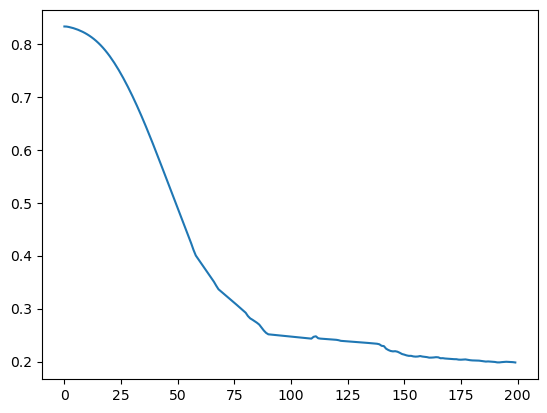

Test loss: 13.707463326876155


In [195]:
train_model(bc_model, LR, 200)


In [197]:
bc_model.stg.get_gate_active_probs()

tensor([9.9958e-01, 9.9905e-01, 1.6497e-01, 9.9962e-01, 9.9797e-01, 7.2325e-02,
        9.7852e-02, 5.3217e-02, 2.2126e-02, 1.5082e-02, 5.3194e-01, 4.2081e-03,
        3.3967e-01, 4.0197e-01, 1.3426e-02, 9.3952e-01, 8.9096e-03, 1.9822e-01,
        3.5718e-01, 5.3954e-02, 1.6279e-02, 1.1473e-01, 2.2063e-02, 2.1978e-02,
        1.6090e-01, 2.1880e-01, 3.6561e-01, 2.4464e-01, 2.9038e-01, 2.1373e-01,
        9.6258e-02, 9.6542e-02, 1.3812e-01, 1.2798e-01, 2.0112e-01, 1.3626e-01,
        7.2479e-03, 9.2416e-02, 4.8399e-01, 2.1437e-02, 8.5403e-02, 2.3989e-01,
        1.7035e-02, 1.2439e-01, 1.1798e-02, 1.5790e-01, 4.3049e-03, 4.7525e-01,
        8.5447e-02, 1.9759e-02, 1.9462e-01, 1.9400e-01, 6.2793e-01, 7.3432e-02,
        3.3251e-01, 2.2803e-01, 6.9073e-03, 5.2483e-02, 4.2243e-01, 3.3897e-02,
        4.8913e-02, 3.1643e-01, 3.4804e-01, 1.7562e-02, 1.3718e-01, 9.5357e-03,
        1.1463e-01, 6.3252e-02, 2.0838e-01, 1.8606e-02, 1.8058e-01, 3.6428e-01,
        3.8863e-02, 1.0518e-01, 8.4585e-

### Checking features' scores

In our Stochastic Gates, we offer two methods that can be used to obtain features scores.

- `get_gate_values()` get the expected values of gates associated with each feature
- `get_gate_active_probs()` get the probability that a gate is open (i.e probability > 0)

In [ ]:
# Rank all features based on their raw scores (gate values)
def rank_features(scores):
    scores_index = [(s, i) for (i, s) in enumerate(scores)]
    return sorted(scores_index, reverse=True)

# Get ranks of informative features only
def get_rank_of_informative_features(rank_features):
    '''
    Return list of [rank, original_feature_index]
    '''
    informative_features = set(range(5))
    result = []
    
    for rank, (val, i) in enumerate(rank_features):
        if i in informative_features:
            result.append((rank, i))
    
    return torch.Tensor(result)

## Baseline model

In [ ]:
baseline_lr = 0.01
baseline_num_epochs = 350

baseline_model = MLP(input_size=input_size)

In [ ]:
trained_baseline_model_dict = train_model(baseline_model, baseline_lr, baseline_num_epochs)

In [ ]:
plot_losses(baseline_num_epochs, trained_baseline_model_dict['train_losses'])

## Stochastic Gates

### Using Gaussian distribution to relax Bernoulli

In the following example, we will specifically investigate how one can use GaussianStochasticGates as a STG choice to train the network and retrieve features importance scores.

![Gaussian for STG](./img/gaussian_stg.png)

Recall from our earlier figure of training neural network with stochastic gates, each stochastic gate $z_d$ is drawn from the STG approximation of the Bernoulli distribution (shown as the blue histogram on the right). Specifically, $z_d$ is obtained by applying the hard-sigmoid function to a mean-shifted Gaussian random variable.

#### Note on hyperparameters

To save space and keep things straightforward, we performed a grid search of these hyperparameters separately and found the following values to result in relatively desirable performance for our model. 

In [ ]:
gaussian_lr_mlp = 0.01
gaussian_lr_stg = 0.1
gaussian_num_epochs = 350

gaussian_stg = GaussianStochasticGates(n_gates=input_size, reg_weight=gaussian_lr_stg)
gaussian_model = MLP(input_size=input_size, stochastic_gates=gaussian_stg)

From checking model's parameters, we can see that `mu` is part of the parameters list. This signifies that the training process will learn parameters of our regression model (`weight` and `bias`) as well as that of our Stochastic Gates (`mu`).

In [ ]:
for (name, _) in gaussian_model.named_parameters():
    print(name)

In [ ]:
trained_gaussian_model_dict = train_model(gaussian_model, gaussian_lr_mlp, gaussian_num_epochs)

In [ ]:
plot_losses(gaussian_num_epochs, trained_gaussian_model_dict['train_losses'])

We can inspect more about the model by extracting from `trained_gaussian_model_dict`.

In [ ]:
trained_gaussian_model = trained_gaussian_model_dict["model"]
gaussian_gate_values = trained_gaussian_model.stg.get_gate_values()
gaussian_gate_active_probs = trained_gaussian_model.stg.get_gate_active_probs()

#### Checking raw scores 
We can see that 4 out of 5 informative features have scores of 1, which is a clear indication that they will be selected if passed through our gates.

In [ ]:
gaussian_gate_values[:20]

#### Understanding results

We can see that from checking the rankings of the original 5 informative features, 4 out of 5 are ranked within the top 5, showing the accuracy of 80%. 

In [ ]:
get_rank_of_informative_features(rank_features(gaussian_gate_values))

### Background on Hard Kuma distribution ...

The Kuma distribution is a two-parameters distribution over the open interval $(0, 1)$, we denote a Kumaraswamy distributed variable by $K \sim Kuma(a, b)$, where $a \in R_{>0}$ and $b \in R_{>0}$ control the distribution’s shape.

The HardKuma distribution, which is what we use as the underlying implementation for `KumaStochasticGates` is obtained by starting from a $Kuma(0.5, 0.5)$, and stretching its support to the interval $(−0.1, 1.1)$. Finally we collapse all mass before $0$ to ${0}$ and all mass after $1$ to ${1}$ by applying a hard-sigmoid on it (hence the name Hard Kuma).

In the following figure, Kuma is the dashed line, where HardKuma is the continuous line. Notice that these share a lot of similarities with the [Binary Concrete](#Hard-Binary-Concrete-distribution-to-relax-Bernoulli) distribution which will be discussed below.

![(Kuma distribution](./img/kuma_stg.png)

### .. and Hard Binary Concrete distribution

The parameters of the Hard Binary Concrete distribution are $\theta = (log_{\alpha}, \beta)$, where $log_{\alpha}$ is the location and $\beta$ is the temperature. 

It is important to note that the temperature $\beta$ controls the degree of approximation, as with $\beta = 0$ we can recover the original Bernoulli r.v. (but lose the differentiable properties) whereas with $0 < \beta < 1$ we obtain a probability density that concentrates its mass near the endpoints.

We can then “stretch” this distribution to the $(\gamma, \zeta)$ interval, with $\gamma < 0$ and $\zeta > 1$, then apply the hard-sigmoid on it (similarly to Hard Kuma).

The result can be seen in the following figure.

![Binary Concrete Distribution](./img/binaryconcrete_stg.png)

## Experiement Analysis

### Experiments across Gaussian, Binary Concrete, and Kuma

Now that we know how to incorporate Stochastic Gates into a simple regression neural network, we will explore the effectiveness of the three underlying distributions. To do so, we will run our experiment 10 times for each distribution and look at the following metrics:

1. ***Average MSE Loss***: this reveals the accuracy of the overall MLP (with embedded Stochastic Gates) in correctly performing the regression task


2. ***Median of median ranks***: median ranks are computed from ranking the informative features by their raw scores. The median of all experiments will reveal how high or low the informative features are ranked. A higher rank reveals that the algorithm is more effective in identifying important features.

3. ***Worst rank across runs***: worst rank associated with any of the 5 informative features. This allows us to see cases where distributions make mistake, and how bad they do so.

In [ ]:
# Setting up hyperparameters for Kuma and Binary Concrete

kuma_lr_mlp = 0.01
kuma_lr_stg = 0.01
kuma_num_epochs = 350

bc_lr_mlp = 0.01
bc_lr_stg = 0.01
bc_num_epochs = 350

In [ ]:
number_of_runs = 10

def run_experiment(model_type, optimal_lr_stg, optimal_lr_mlp, num_epochs):
    accuracies = list()
    median_ranks = list()
    models_list = list()

    for run in range(number_of_runs):
        if model_type == 'gaussian':
            stg_exp = GaussianStochasticGates(n_gates=input_size, reg_weight=optimal_lr_stg)
        elif model_type == 'kuma':
            stg_exp = KumaStochasticGates(n_gates=input_size, reg_weight=optimal_lr_stg)
        elif model_type == 'binary_concrete':
            stg_exp = BinaryConcreteStochasticGates(n_gates=input_size, reg_weight=optimal_lr_stg)
        elif model_type == 'baseline':
            stg_exp = None

        model_exp = MLP(input_size=input_size, stochastic_gates=stg_exp)
        trained_dict_exp = train_model(model_exp, optimal_lr_mlp, num_epochs)
        trained_model_exp = trained_dict_exp["model"]

        # Store a list of models so we can see each specific run
        models_list.append(trained_model_exp)
        
        # Store accuracies
        accuracies.append(trained_dict_exp["test_loss"])

        # Compute and store median rank
        if trained_model_exp.stg:
            gate_values_exp = trained_model_exp.stg.get_gate_values()
            features_ranks = rank_features(gate_values_exp)
            informative_features_rank = get_rank_of_informative_features(features_ranks)
            median_rank_exp = torch.median(informative_features_rank[:,0])
            median_ranks.append(median_rank_exp)
        
        if (run + 1) % 5 == 0:
            print(f"Run {run + 1} finished")
        
    return torch.Tensor(accuracies), torch.Tensor(median_ranks), models_list

### Note

Running these cells below can take a ***very long time***.

In [ ]:
baseline_accs, _, baseline_models_list = run_experiment('baseline', None, baseline_lr, baseline_num_epochs)

In [ ]:
gaussian_accs, gaussian_meds, gaussian_models_list = run_experiment('gaussian', gaussian_lr_stg, gaussian_lr_mlp, gaussian_num_epochs)

In [ ]:
kuma_accs, kuma_meds, kuma_models_list = run_experiment('kuma', kuma_lr_stg, kuma_lr_mlp, kuma_num_epochs)

In [ ]:
bc_accs, bc_meds, bc_models_list = run_experiment('binary_concrete', bc_lr_stg, bc_lr_mlp, bc_num_epochs)

### Loading model after experiments and plotting

In [ ]:
baseline_lr = 0.01
baseline_num_epochs = 350

gaussian_lr_mlp = 0.01
gaussian_lr_stg = 0.1
gaussian_num_epochs = 350

kuma_lr_mlp = 0.01
kuma_lr_stg = 0.01
kuma_num_epochs = 350

bc_lr_mlp = 0.01
bc_lr_stg = 0.01
bc_num_epochs = 350

def initialize_stochastic_gates(model_type):
    if model_type == "gaussian":
        return GaussianStochasticGates(input_size, reg_weight=gaussian_lr_stg)
    
    if model_type == "kuma":
        return KumaStochasticGates(input_size, reg_weight=kuma_lr_stg)
    
    if model_type == "bc":
        return BinaryConcreteStochasticGates(input_size, reg_weight=bc_lr_stg)
    
    return None

def load_models(model_type):
    assert model_type in ["gaussian", "bc", "kuma", "baseline"]
    models = []
    
    for i in range(0, 10):
        t = initialize_stochastic_gates(model_type)
        m = MLP(input_size, t)
        m.load_state_dict(torch.load(f'./model_state_dicts/{model_type}_run_{i}.pth'))
        models.append(m)
        
    return models

def find_med_rank(stg):
    curr_gate_vals = stg.get_gate_values()
    features_ranks = rank_features(curr_gate_vals)
    informative_features_rank = get_rank_of_informative_features(features_ranks)
    median_rank_exp = torch.median(informative_features_rank[:,0])
    
    return float(median_rank_exp)

def find_worst_rank(stg):
    curr_gate_vals = stg.get_gate_values()
    features_ranks = rank_features(curr_gate_vals)
    informative_features_rank = get_rank_of_informative_features(features_ranks)
    
    worst_rank = sorted(informative_features_rank, key=lambda x : x[0], reverse=True)[0]
    return worst_rank

def find_avg_gate_scores(models_list):
    """
    Return tensor([average_score_5_informative, max_avg_of_noisy])
    """
    gate_scores = [x.stg.get_gate_values() for x in models_list]
    gate_scores = torch.stack(tuple(gate_scores))
    
    avg_gate_scores = gate_scores.mean(0)
    max_avg_noisy = torch.max(avg_gate_scores[5:], dim=0, keepdim=True).values
    avg_informative = avg_gate_scores[:5]
    
    return torch.hstack((avg_informative, max_avg_noisy))

def box_plot(data, xlabel, ylabel, plot_title, **kwargs):
    plt.figure(figsize=(15, 9))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(plot_title)
    bp = plt.boxplot(data,
              positions=[1, 2, 3, 4],
              labels=['baseline', 'gaussian','kuma','binary concrete'], **kwargs)
    plt.legend([bp['medians'][0], bp['means'][0]], ['median', 'mean'])
    plt.show()
    
def bar_plot(gaussian_data, kuma_data, bc_data, **kwargs):
    assert len(gaussian_data) == len(kuma_data)
    assert len(kuma_data) == len(bc_data)
    
    colors = ['lightskyblue'] * 5 + ['crimson']
    
    # Create proxy legend for color groups
    leg_colors = {'informative':'lightskyblue', 'noisy (max)':'crimson'}         
    leg_labels = list(leg_colors.keys())
    leg_handles = [plt.Rectangle((0,0),1,1, color=leg_colors[label]) for label in leg_labels]
    
    plt.figure(figsize=(15, 9))
    
    plt.bar(np.arange(6), gaussian_data, label ='gaussian', color=colors)
    plt.bar(np.arange(6) + 8, kuma_data, label ='kuma', color=colors)
    plt.bar(np.arange(6) + 16, bc_data, label ='binary_concrete', color=colors)
    
    plt.xlabel('Distributions')
    plt.ylabel('Avg gate values')
    plt.xticks([2.5, 10.5, 18.5], ['gaussian', 'kuma', 'binary_concrete'])
    plt.title("Average gate values of informative and noisy features across distribution")
    plt.legend(leg_handles, leg_labels)
    plt.show()

In [ ]:
baseline_models_list = load_models("baseline")
gaussian_models_list = load_models("gaussian")
kuma_models_list = load_models("kuma")
bc_models_list = load_models("bc")

### Loss analysis

We will look at MSE loss across 10 runs for each model. 

In [ ]:
baseline_accs = []
gaussian_accs = []
kuma_accs = []
bc_accs = []

for i in range(10):
    gau_m = gaussian_models_list[i]
    gaussian_accs.append(test_loop(test_loader, gau_m, nn.MSELoss()))
    
    kuma_m = kuma_models_list[i]
    kuma_accs.append(test_loop(test_loader, kuma_m, nn.MSELoss()))
    
    bc_m = bc_models_list[i]
    bc_accs.append(test_loop(test_loader, bc_m, nn.MSELoss()))
    
    bl_m = baseline_models_list[i]
    baseline_accs.append(test_loop(test_loader, bl_m, nn.MSELoss()))

In [ ]:
box_plot([baseline_accs, gaussian_accs, kuma_accs, bc_accs], 
         xlabel='Distributions', 
         ylabel='MSE Loss', 
         plot_title='MSE Losses across distributions',
         showmeans=True,
         meanline=True)

Observe that Gaussian excels in both MSE Loss as well as having a lower variance.

This agrees with our original understanding of each distribution, as one of the advantages of using Gaussian's distribution to smooth Bernoulli over Binary Concrete is the fact that it has lower variance. 

Given that, Kuma seems to be an in-between option, with loss lower than that of Gaussian, and variance lower than that of Binary Concrete.

### Getting a look at gate values across distributions

In [ ]:
gaussian_avg_gate_scores = find_avg_gate_scores(gaussian_models_list)
kuma_avg_gate_scores = find_avg_gate_scores(kuma_models_list)
bc_avg_gate_scores = find_avg_gate_scores(bc_models_list)

In [ ]:
bar_plot(gaussian_avg_gate_scores, kuma_avg_gate_scores, bc_avg_gate_scores)

This plot is done by computing the averages gate values across 10 runs from the 5 informative features. To represent the noisy features, we pick the maximum average of the remaining 495.

This plot reveals a few interesting points:

- With `350` epochs, Gaussian STG leads to more stronger gate values (closer to 1), while the other two result in weaker signals
- All three STGs give rather weak signal for the third feature, which corresponds to the polynomial term
- The third term is also ranked lower than other noisy features

### Worst rank analysis

In [ ]:
gaussian_worst_ranks = []
kuma_worst_ranks = []
bc_worst_ranks = []

for i in range(10):
    gaussian_worst_ranks.append(find_worst_rank(gaussian_models_list[i].stg))
    kuma_worst_ranks.append(find_worst_rank(kuma_models_list[i].stg))
    bc_worst_ranks.append(find_worst_rank(bc_models_list[i].stg))

# Extract just the ranks
g_wr = [x[0] for x in gaussian_worst_ranks]
k_wr = [x[0] for x in kuma_worst_ranks]
bc_wr = [x[0] for x in bc_worst_ranks]

In [ ]:
box_plot([g_wr, k_wr, bc_wr], 
         xlabel='Distributions', 
         ylabel='Rank', 
         plot_title='Worst rank of informative features across distributions',
         showmeans=True,
         meanline=True)

From the previous metric (`gate_values` for informative and noisy features), we can see that the third term often gets ranked much lower compare to the remaining 4 of the informative features group.

This section explores the ranking of that specific third term. We can see here that Gaussian tends to give it a higher rank than both Kuma and Binary Concrete. This *might* mean that Gaussian can better identify the polynomial feature, but it would still require further investigation to get a conclusive answer. 